### Analyse Statistique — Projet Fil Rouge
### Tests ANOVA, Corrélation, Normalité

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, pearsonr, spearmanr, shapiro, kruskal
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
 
print("Librairies chargées ✅")

Librairies chargées ✅


In [2]:
df = pd.read_csv('../data/final/master_clean.csv')
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Pays : {df['country_code'].nunique()}")
print(f"Années : {df['year'].min()} - {df['year'].max()}")
df.head()

Dataset : 1222 lignes, 22 colonnes
Pays : 169
Années : 2015 - 2024


,country_code,year,gdp_growth,inflation,population,gni_per_capita,life_expectancy,literacy_rate,country_name,region,...,happiness_score,social_support,life_expectancy_whr,freedom,generosity,corruption,positive_affect,negative_affect,attractivity_score,imputation_notes
0,ABW,2015,3.611480,-0.661709,107906.0,25430.0,62.270,90.149999,Aruba,Latin America & Caribbean,...,5.897462,0.836077,64.178788,0.775615,-0.007821,0.804308,0.715582,0.289328,0.542957,NaN
1,ABW,2016,1.234335,4.383892,108727.0,25560.0,62.646,91.656315,Aruba,Latin America & Caribbean,...,5.877889,0.848111,64.370115,0.781889,-0.001876,0.814111,0.721258,0.291674,0.524718,NaN
2,ABW,2017,3.493430,4.975952,108735.0,26460.0,62.406,91.484300,Aruba,Latin America & Caribbean,...,5.946824,0.855471,64.380952,0.818647,-0.024640,0.791706,0.707814,0.302965,0.529338,NaN
3,ABW,2018,3.212471,0.626149,108908.0,27970.0,62.443,91.479241,Aruba,Latin America & Caribbean,...,6.006806,0.851139,64.608602,0.841000,-0.022560,0.804278,0.713189,0.303968,0.561154,NaN
4,ABW,2019,1.225112,2.302373,109203.0,29320.0,62.941,91.433149,Aruba,Latin America & Caribbean,...,6.038588,0.837275,65.147253,0.842039,-0.016412,0.801078,0.707263,0.301591,0.560620,NaN


In [3]:
print("=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
 
cols = ['happiness_score', 'gdp_per_capita', 'life_expectancy',
        'freedom', 'corruption', 'social_support']
 
desc = df[cols].describe().round(3)
print(desc)
 
# Par région
print("\n--- Bonheur moyen par région ---")
region_stats = df.groupby('region')['happiness_score'].agg(
    ['mean', 'std', 'min', 'max', 'count']
).round(3).sort_values('mean', ascending=False)
print(region_stats)

STATISTIQUES DESCRIPTIVES
       happiness_score  gdp_per_capita  life_expectancy   freedom  corruption  \
count         1222.000        1222.000         1222.000  1222.000    1222.000   
mean             5.530       18052.683           63.187     0.789       0.731   
std              0.969       22918.124            1.851     0.107       0.149   
min              2.375         219.425           60.417     0.304       0.047   
25%              4.793        2971.245           62.270     0.729       0.673   
50%              5.649        7410.338           62.646     0.814       0.775   
75%              6.148       25123.249           65.617     0.863       0.814   
max              7.889      142855.375           66.035     0.984       0.963   

       social_support  
count        1222.000  
mean            0.804  
std             0.108  
min             0.420  
25%             0.725  
50%             0.832  
75%             0.888  
max             0.985  

--- Bonheur moyen par régio

# Test de normalité (Shapiro-Wilk)

In [4]:
print("=" * 60)
print("TEST DE NORMALITÉ — Shapiro-Wilk")
print("H0 : la distribution est normale")
print("=" * 60)
 
for col in ['happiness_score', 'gdp_per_capita']:
    # Shapiro sur un échantillon (max 5000)
    sample = df[col].dropna().sample(min(500, len(df[col].dropna())), random_state=42)
    stat, p = shapiro(sample)
    conclusion = "NON normale" if p < 0.05 else "Normale"
    print(f"\n{col}:")
    print(f"  Statistique W = {stat:.4f}")
    print(f"  p-value = {p:.4f}")
    print(f"  Conclusion : Distribution {conclusion} (α=0.05)")

TEST DE NORMALITÉ — Shapiro-Wilk
H0 : la distribution est normale

happiness_score:
  Statistique W = 0.9840
  p-value = 0.0000
  Conclusion : Distribution NON normale (α=0.05)

gdp_per_capita:
  Statistique W = 0.7380
  p-value = 0.0000
  Conclusion : Distribution NON normale (α=0.05)


# Test ANOVA : Bonheur par région

TEST ANOVA — Bonheur par région
H0 : les moyennes de bonheur sont égales entre toutes les régions
H1 : au moins une région a une moyenne différente

F-statistique = 196.0940
p-value = 0.000000

✅ RÉSULTAT : On REJETTE H0
→ Il existe une différence significative de bonheur entre les régions
→ La région d'appartenance influence le bonheur (p < 0.05)


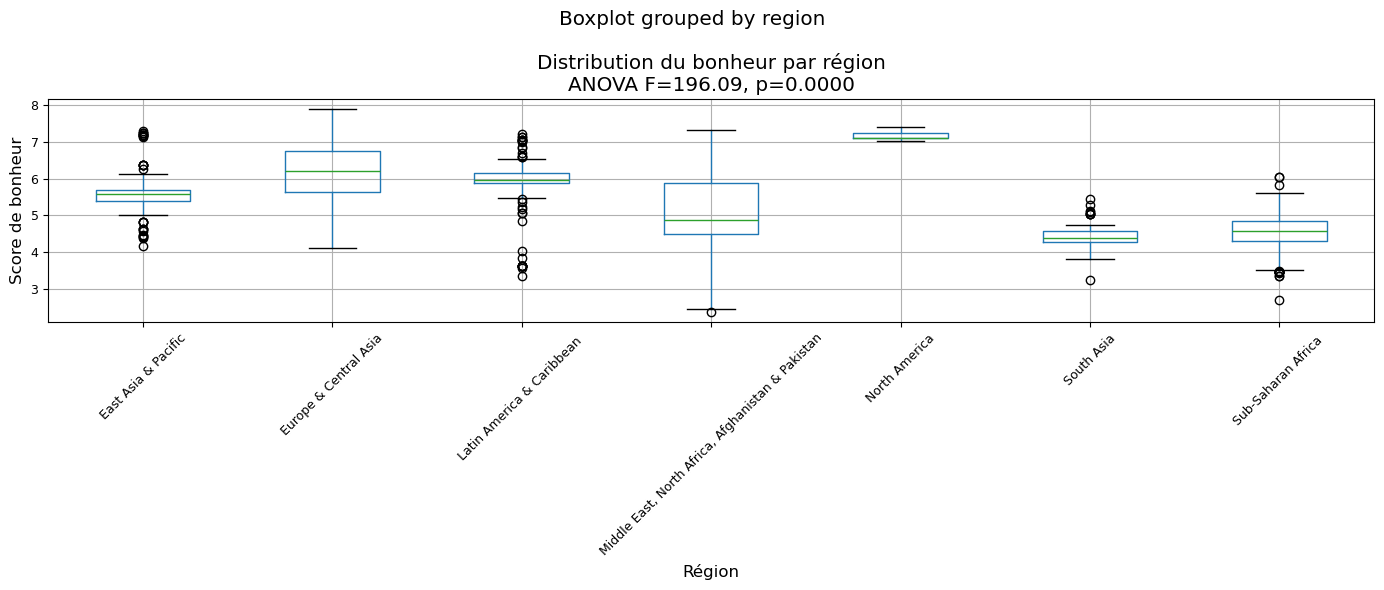

Graphique sauvegardé ✅


In [5]:
print("=" * 60)
print("TEST ANOVA — Bonheur par région")
print("H0 : les moyennes de bonheur sont égales entre toutes les régions")
print("H1 : au moins une région a une moyenne différente")
print("=" * 60)
 
groupes = [group['happiness_score'].dropna().values
           for name, group in df.groupby('region')]
 
f_stat, p_anova = f_oneway(*groupes)
print(f"\nF-statistique = {f_stat:.4f}")
print(f"p-value = {p_anova:.6f}")
 
if p_anova < 0.05:
    print("\n✅ RÉSULTAT : On REJETTE H0")
    print("→ Il existe une différence significative de bonheur entre les régions")
    print("→ La région d'appartenance influence le bonheur (p < 0.05)")
else:
    print("\nRÉSULTAT : On NE REJETTE PAS H0")
    print("→ Pas de différence significative entre les régions")
 
# Visualisation ANOVA
fig, ax = plt.subplots(figsize=(14, 6))
df.boxplot(column='happiness_score', by='region', ax=ax,
           rot=45, fontsize=9)
ax.set_title(f'Distribution du bonheur par région\nANOVA F={f_stat:.2f}, p={p_anova:.4f}')
ax.set_xlabel('Région')
ax.set_ylabel('Score de bonheur')
plt.tight_layout()
plt.savefig('../reports/plots/anova_bonheur_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✅")

# Test de Kruskal-Wallis (alternative non-paramétrique)

In [6]:
print("=" * 60)
print("TEST KRUSKAL-WALLIS — Bonheur par niveau de revenu")
print("(Test non-paramétrique — ne suppose pas la normalité)")
print("H0 : les distributions sont identiques entre les groupes")
print("=" * 60)
 
groupes_income = [group['happiness_score'].dropna().values
                  for name, group in df.groupby('income_level')]
 
h_stat, p_kruskal = kruskal(*groupes_income)
print(f"\nH-statistique = {h_stat:.4f}")
print(f"p-value = {p_kruskal:.6f}")
 
if p_kruskal < 0.05:
    print("\n✅ RÉSULTAT : Différence significative de bonheur selon le niveau de revenu")
    print("→ Les pays riches sont significativement plus heureux (p < 0.05)")
else:
    print("\nRÉSULTAT : Pas de différence significative")

TEST KRUSKAL-WALLIS — Bonheur par niveau de revenu
(Test non-paramétrique — ne suppose pas la normalité)
H0 : les distributions sont identiques entre les groupes

H-statistique = 708.6773
p-value = 0.000000

✅ RÉSULTAT : Différence significative de bonheur selon le niveau de revenu
→ Les pays riches sont significativement plus heureux (p < 0.05)


# Corrélation de Pearson : PIB vs Bonheur

CORRÉLATION DE PEARSON — PIB vs Bonheur
H0 : pas de corrélation linéaire entre PIB et Bonheur

Coefficient r = 0.7782
p-value = 0.000000
R² = 0.6056 (60.6% de la variance expliquée)

✅ RÉSULTAT : Corrélation forte et significative (p < 0.05)
→ Un PIB plus élevé est associé à un bonheur plus élevé


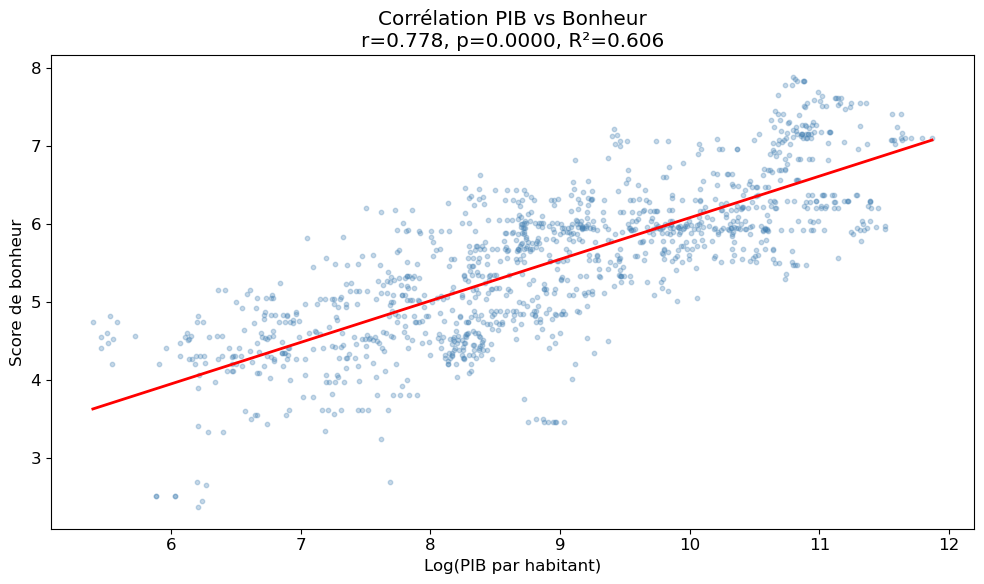

Graphique sauvegardé ✅


In [7]:
print("=" * 60)
print("CORRÉLATION DE PEARSON — PIB vs Bonheur")
print("H0 : pas de corrélation linéaire entre PIB et Bonheur")
print("=" * 60)
 
df_clean = df[['gdp_per_capita', 'happiness_score']].dropna()
r, p_pearson = pearsonr(np.log(df_clean['gdp_per_capita'] + 1),
                         df_clean['happiness_score'])
 
print(f"\nCoefficient r = {r:.4f}")
print(f"p-value = {p_pearson:.6f}")
print(f"R² = {r**2:.4f} ({r**2*100:.1f}% de la variance expliquée)")
 
if p_pearson < 0.05:
    if r > 0.5:
        force = "forte"
    elif r > 0.3:
        force = "modérée"
    else:
        force = "faible"
    print(f"\n✅ RÉSULTAT : Corrélation {force} et significative (p < 0.05)")
    print(f"→ Un PIB plus élevé est associé à un bonheur plus élevé")
 
# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(np.log(df_clean['gdp_per_capita'] + 1),
           df_clean['happiness_score'],
           alpha=0.3, color='steelblue', s=10)
z = np.polyfit(np.log(df_clean['gdp_per_capita'] + 1),
               df_clean['happiness_score'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_clean['gdp_per_capita'].apply(lambda x: np.log(x+1)).min(),
                     df_clean['gdp_per_capita'].apply(lambda x: np.log(x+1)).max(), 100)
ax.plot(x_line, p_line(x_line), "r-", linewidth=2)
ax.set_xlabel('Log(PIB par habitant)')
ax.set_ylabel('Score de bonheur')
ax.set_title(f'Corrélation PIB vs Bonheur\nr={r:.3f}, p={p_pearson:.4f}, R²={r**2:.3f}')
plt.tight_layout()
plt.savefig('../reports/plots/correlation_pib_bonheur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✅")
 

# Matrice de corrélations complète

MATRICE DE CORRÉLATIONS — Spearman
                 happiness_score  gdp_per_capita  life_expectancy  freedom  \
happiness_score            1.000           0.793            0.039    0.547   
gdp_per_capita             0.793           1.000            0.051    0.426   
life_expectancy            0.039           0.051            1.000    0.041   
freedom                    0.547           0.426            0.041    1.000   
corruption                -0.271          -0.324            0.003   -0.358   
social_support             0.821           0.775            0.026    0.480   
generosity                -0.047          -0.101           -0.051    0.108   

                 corruption  social_support  generosity  
happiness_score      -0.271           0.821      -0.047  
gdp_per_capita       -0.324           0.775      -0.101  
life_expectancy       0.003           0.026      -0.051  
freedom              -0.358           0.480       0.108  
corruption            1.000          -0.230      -

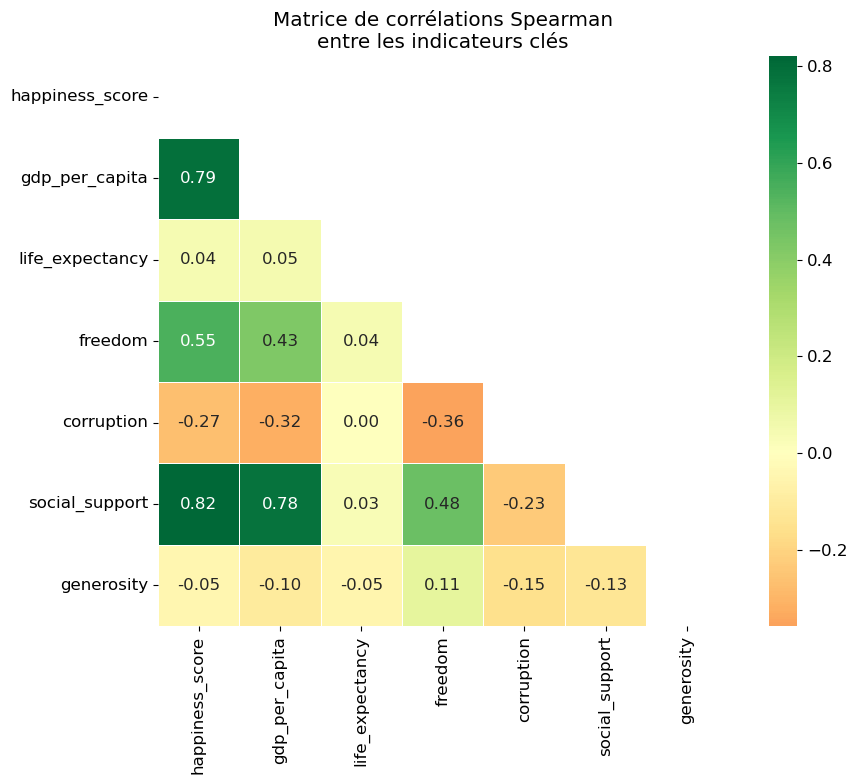

Graphique sauvegardé ✅


In [8]:
print("=" * 60)
print("MATRICE DE CORRÉLATIONS — Spearman")
print("=" * 60)
 
cols_corr = ['happiness_score', 'gdp_per_capita', 'life_expectancy',
             'freedom', 'corruption', 'social_support', 'generosity']
 
corr_matrix = df[cols_corr].corr(method='spearman').round(3)
print(corr_matrix)
 
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matrice de corrélations Spearman\nentre les indicateurs clés')
plt.tight_layout()
plt.savefig('../reports/plots/matrice_correlations_spearman.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✅")
 

# ANOVA : Évolution pré vs post COVID

In [9]:
print("=" * 60)
print("TEST T — Bonheur Pré-Covid vs Post-Covid")
print("H0 : pas de différence de bonheur avant et après le Covid")
print("=" * 60)
 
pre_covid = df[df['year'] < 2020]['happiness_score'].dropna()
post_covid = df[df['year'] >= 2020]['happiness_score'].dropna()
 
print(f"\nPré-Covid (2015-2019) : moyenne = {pre_covid.mean():.3f}, n={len(pre_covid)}")
print(f"Post-Covid (2020-2024) : moyenne = {post_covid.mean():.3f}, n={len(post_covid)}")
 
t_stat, p_ttest = stats.ttest_ind(pre_covid, post_covid)
print(f"\nt-statistique = {t_stat:.4f}")
print(f"p-value = {p_ttest:.4f}")
 
if p_ttest < 0.05:
    diff = post_covid.mean() - pre_covid.mean()
    direction = "augmenté" if diff > 0 else "diminué"
    print(f"\n✅ RÉSULTAT : Le bonheur a significativement {direction} après le Covid")
    print(f"→ Variation moyenne : {diff:+.3f} points")
else:
    print("\nRÉSULTAT : Pas de différence significative pré/post Covid")
 

TEST T — Bonheur Pré-Covid vs Post-Covid
H0 : pas de différence de bonheur avant et après le Covid

Pré-Covid (2015-2019) : moyenne = 5.474, n=622
Post-Covid (2020-2024) : moyenne = 5.587, n=600

t-statistique = -2.0342
p-value = 0.0421

✅ RÉSULTAT : Le bonheur a significativement augmenté après le Covid
→ Variation moyenne : +0.113 points


# Résumé final

In [10]:
print("\n" + "=" * 60)
print("RÉSUMÉ DES TESTS STATISTIQUES")
print("=" * 60)
print(f"""
Test                          | Résultat
------------------------------|----------------------------------
Normalité happiness_score     | Non normale (Shapiro-Wilk)
ANOVA régions                 | F={f_stat:.2f}, p={p_anova:.4f} → Significatif
Kruskal-Wallis income_level   | H={h_stat:.2f}, p={p_kruskal:.4f} → Significatif  
Corrélation PIB-Bonheur       | r={r:.3f}, p={p_pearson:.4f} → Significatif
Test T pré/post Covid         | t={t_stat:.3f}, p={p_ttest:.4f}
""")
print("Analyse statistique terminée ✅")
print("Graphiques sauvegardés dans reports/plots/")


RÉSUMÉ DES TESTS STATISTIQUES

Test                          | Résultat
------------------------------|----------------------------------
Normalité happiness_score     | Non normale (Shapiro-Wilk)
ANOVA régions                 | F=196.09, p=0.0000 → Significatif
Kruskal-Wallis income_level   | H=708.68, p=0.0000 → Significatif  
Corrélation PIB-Bonheur       | r=0.778, p=0.0000 → Significatif
Test T pré/post Covid         | t=-2.034, p=0.0421

Analyse statistique terminée ✅
Graphiques sauvegardés dans reports/plots/
